In [1]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [2]:
with open('/lustre/scratch127/qpg/jc59/circuit_depths/results30.pkl', 'rb') as f:
    res = pickle.load(f)

In [46]:
res['test_N2_W2']

{'default': (106, 95), 'rz': (94, 72, 3), 'rzz': (89, 75, 3)}

In [39]:
# qubits = [ 6, 9, 12, 20, 24, 24, 8, 12, 16, 20, 10, 15, 20, 25, 30, 30, 30] #, 35]
qubits = [ 6, 9, 12, 20, 24, 8, 12, 16, 10, 15, 25, 30] #, 35]

default_depths, default_counts = [], []
rzz_depths, rzz_counts = [], []
rz_depths, rz_counts = [], []

# for filename in [
#         'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
#         'test_N4_W6', 
#         'test_N5_W6', 'test_N7_W2', 'test_N7_W3',
#         'test_N7_W4', 'test_N7_W5', 
#         'test_N8_W2', 'test_N8_W3','test_N8_W4', 'test_N8_W5', 'test_N8_W6',
#         'test_N9_W6', 'test_N10_W6'# ,'test_N14_W7'
# ]:
for filename in [
        'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
        'test_N4_W6', 
        # 'test_N5_W6', 
        'test_N7_W2', 'test_N7_W3',
        'test_N7_W4', 
        # 'test_N7_W5', 
        'test_N8_W2', 'test_N8_W3',
        # 'test_N8_W4', 
        'test_N8_W5', 'test_N8_W6',
        # 'test_N9_W6', 'test_N10_W6' ,'test_N14_W7'
]:
    default_depths.append(res[filename]['default'][1])
    default_counts.append(res[filename]['default'][0])
    rzz_depths.append(res[filename]['rzz'][1])
    rzz_counts.append(res[filename]['rzz'][0])
    rz_depths.append(res[filename]['rz'][1])
    rz_counts.append(res[filename]['rz'][0])

[array([7.51393562]), np.int32(2), array([1.14666718, 0.82774052]), np.float64(2.6645352591003757e-15)]


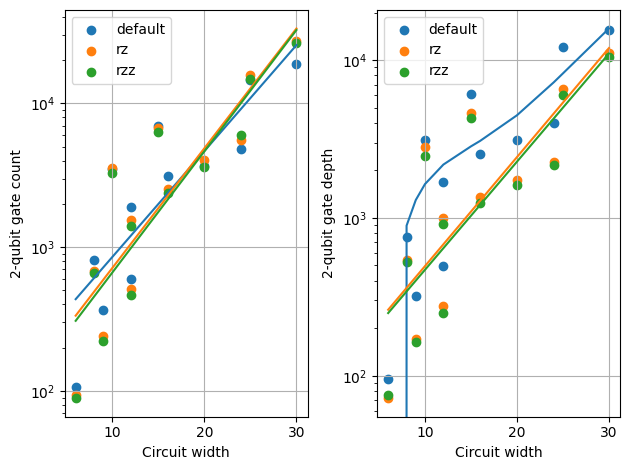

In [40]:
fig, axes = plt.subplots(1, 2)
axes[0].set_yscale('log')
axes[0].scatter(qubits, default_counts, label='default')
axes[0].scatter(qubits, rz_counts, label='rz')
axes[0].scatter(qubits, rzz_counts, label='rzz')
axes[0].legend()

plot_qubits = sorted(list(set(qubits)))
p_counts_default, full = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(default_counts), 1, full=True)
axes[0].plot(plot_qubits, np.exp(p_counts_default(plot_qubits)))
print(full)

p_counts_rz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rz_counts), 1)
axes[0].plot(plot_qubits, np.exp(p_counts_rz(plot_qubits)))

p_counts_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rzz_counts), 1)
axes[0].plot(plot_qubits, np.exp(p_counts_rzz(plot_qubits)))

axes[1].set_yscale('log')
axes[1].scatter(qubits, default_depths, label='default')
axes[1].scatter(qubits, rz_depths, label='rz')
axes[1].scatter(qubits, rzz_depths, label='rzz')
axes[1].legend()

plot_qubits = sorted(list(set(qubits)))
p_depths_default = np.polynomial.polynomial.Polynomial.fit(qubits, default_depths, 3)
axes[1].plot(plot_qubits, p_depths_default(plot_qubits))

p_depths_rz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rz_depths), 1)
axes[1].plot(plot_qubits, np.exp(p_depths_rz(plot_qubits)))

p_depths_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, np.log(rzz_depths), 1)
axes[1].plot(plot_qubits, np.exp(p_depths_rzz(plot_qubits)))


axes[0].set_ylabel('2-qubit gate count')
axes[0].set_xlabel('Circuit width')
axes[1].set_ylabel('2-qubit gate depth')
axes[1].set_xlabel('Circuit width')
axes[0].grid()
axes[1].grid()


fig.tight_layout()
fig.show()

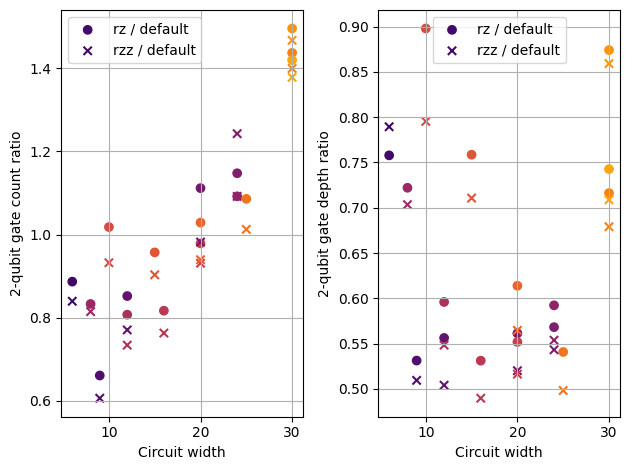

In [62]:
qubits = [ 6, 9, 12, 20, 24, 24, 8, 12, 16, 20, 10, 15, 20, 25, 30, 30, 30] #, 35]

cmap = plt.get_cmap('inferno')
colours = cmap(np.linspace(0.2, 0.8, len(rz_depths)))

default_depths, default_counts = [], []
rzz_depths, rzz_counts = [], []
rz_depths, rz_counts = [], []

for filename in [
        'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
        'test_N4_W6', 
        'test_N5_W6', 'test_N7_W2', 'test_N7_W3',
        'test_N7_W4', 'test_N7_W5', 
        'test_N8_W2', 'test_N8_W3','test_N8_W4', 'test_N8_W5', 'test_N8_W6',
        'test_N9_W6', 'test_N10_W6' # ,'test_N14_W7'
]:
    default_depths.append(res[filename]['default'][1])
    default_counts.append(res[filename]['default'][0])
    rzz_depths.append(res[filename]['rzz'][1])
    rzz_counts.append(res[filename]['rzz'][0])
    rz_depths.append(res[filename]['rz'][1])
    rz_counts.append(res[filename]['rz'][0])

zipped = zip(qubits, default_depths, default_counts, rzz_depths, rzz_counts, rz_depths, rz_counts)
# zipped = sorted(zipped)
qubits, default_depths, default_counts, rzz_depths, rzz_counts, rz_depths, rz_counts = zip(*zipped)

default_counts = np.array(default_counts)
rz_counts = np.array(rz_counts)
rzz_counts = np.array(rzz_counts)

default_depths = np.array(default_depths)
rz_depths = np.array(rz_depths)
rzz_depths = np.array(rzz_depths)

fig, axes = plt.subplots(1, 2)
# axes[0].set_yscale('log')
axes[0].scatter(qubits, rz_counts / default_counts, marker='o', c = colours, label='rz / default')
axes[0].scatter(qubits, rzz_counts / default_counts, marker='x', c = colours, label='rzz / default')
axes[0].legend()

plot_qubits = sorted(list(set(qubits)))
# p_counts_rz = np.polynomial.polynomial.Polynomial.fit(qubits, rz_counts / default_counts, 2)
# axes[0].plot(plot_qubits, p_counts_rz(plot_qubits))
# p_counts_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, rzz_counts / default_counts, 2)
# axes[0].plot(plot_qubits, p_counts_rzz(plot_qubits))

# axes[1].set_yscale('log')


axes[1].scatter(qubits, rz_depths / default_depths, marker='o', c = colours, label='rz / default')
axes[1].scatter(qubits, rzz_depths / default_depths, marker='x', c = colours, label='rzz / default')
axes[1].legend()

# plot_qubits = sorted(list(set(qubits)))
# p_depths_rz = np.polynomial.polynomial.Polynomial.fit(qubits, rz_depths / default_depths, 2)
# axes[1].plot(plot_qubits, p_depths_rz(plot_qubits))
# p_depths_rzz = np.polynomial.polynomial.Polynomial.fit(qubits, rzz_depths / default_depths, 2)
# axes[1].plot(plot_qubits, p_depths_rzz(plot_qubits))


axes[0].set_ylabel('2-qubit gate count ratio')
axes[0].set_xlabel('Circuit width')
axes[1].set_ylabel('2-qubit gate depth ratio')
axes[1].set_xlabel('Circuit width')
axes[0].grid()
axes[1].grid()


fig.tight_layout()
fig.show()

In [44]:
qubits = [ 6, 9, 12, 20, 24, 24, 8, 12, 16, 20, 10, 15, 20, 25, 30, 30, 30, 35]
n = [2,3,3,4,4,4,4,4,4,4,5,5,5,5,5,5,5]
T = [2,3,4,5,6,6,2,3,4,5,2,3,4,5,6,6,6]

default_depths, default_counts = [], []
rzz_depths, rzz_counts = [], []
rz_depths, rz_counts = [], []

for filename in [
        'test_N2_W2', 'trivial', 'test_N3_W4', 'test_N4_W5', 
        'test_N4_W6', 
        'test_N5_W6', 'test_N7_W2', 'test_N7_W3',
        'test_N7_W4', 'test_N7_W5', 
        'test_N8_W2', 'test_N8_W3','test_N8_W4', 'test_N8_W5', 'test_N8_W6',
        'test_N9_W6', 'test_N10_W6' #,'test_N14_W7'
]:
    default_depths.append(res[filename]['default'][1])
    default_counts.append(res[filename]['default'][0])
    rzz_depths.append(res[filename]['rzz'][1])
    rzz_counts.append(res[filename]['rzz'][0])
    rz_depths.append(res[filename]['rz'][1])
    rz_counts.append(res[filename]['rz'][0])
    


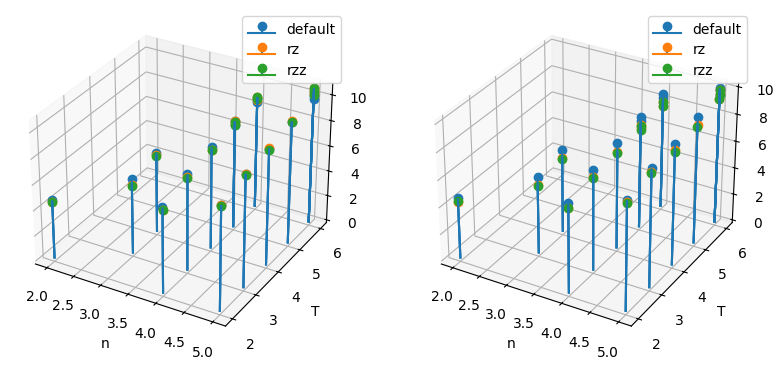

In [36]:
# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=plt.figaspect(0.5))

# =============
# First subplot
# =============
# set up the Axes for the first plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.set_ylabel('T')
ax.set_xlabel('n')
ax.grid()
# ax.set_zlim(50, 20000)
# ax.set_zscale('log')
markerline, stemlines, baseline = ax.stem(n, T, np.log(default_counts), label='default', basefmt='')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rz_counts), label='rz', markerfmt='C1o', linefmt='C0-', basefmt='C1-')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rzz_counts), label='rzz', markerfmt='C2o', linefmt='C0-', basefmt='C2-')
baseline.remove()

ax.legend()

# ==============
# Second subplot
# ==============
# set up the Axes for the second plot
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.set_ylabel('T')
ax.set_xlabel('n')
# ax.set_zlim(50, 20000)
# ax.set_zscale('log')

markerline, stemlines, baseline = ax.stem(n, T, np.log(default_depths), label='default', basefmt='')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rz_depths), label='rz', markerfmt='C1o', linefmt='C0-', basefmt='C1-')
baseline.remove()
markerline, stemlines, baseline = ax.stem(n, T, np.log(rzz_depths), label='rzz', markerfmt='C2o', linefmt='C0-', basefmt='C2-')
baseline.remove()
ax.legend()
plt.show()

